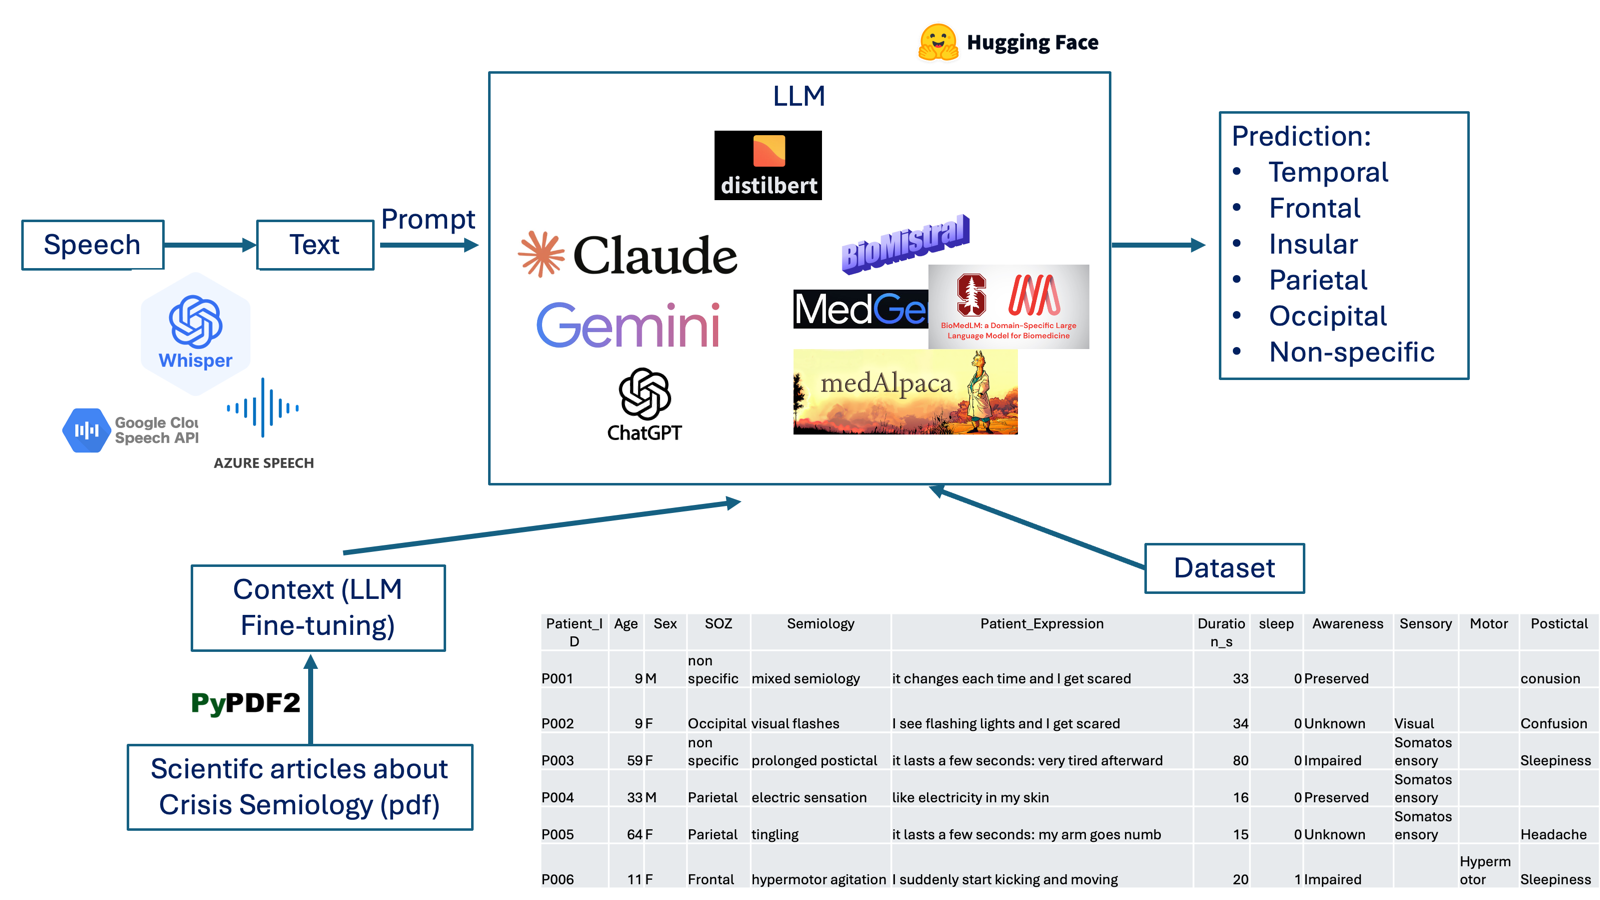

# Install Libraries

In [ ]:
#Install libraries for NLP, deep learning, data handling
!pip install transformers datasets torch scikit-learn pandas
!pip install --upgrade transformers

# Speech to Text
!pip install -q git+https://github.com/openai/whisper.git
!apt-get -qq install ffmpeg


# Import Libraries

In [ ]:
# Data handling & preprocessing
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from datasets import Dataset

# NLP model & HuggingFace
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

# Speech to Text
from IPython.display import Javascript, display
from google.colab import output
from base64 import b64decode

# To use tensor efficiently
import torch

# Import Dataset (Excel)

In [ ]:
# Load Excel
file_path = "/content/realistic_epilepsy_dataset_400.xlsx"
df = pd.read_excel(file_path)

# Quick check of the Dataframe
print(df.head())
print("Number of unique SOZ labels:", df['SOZ'].nunique())

In [ ]:
# To converts categories to numbers
le = LabelEncoder()
df['SOZ_label'] = le.fit_transform(df['SOZ'])


# Data Cleaning

In [ ]:
data = df.copy()  # Copy original DataFrame to avoid modifying it

data = data[data["Patient_Expression"].notna()]  # Drop rows with missing text
data = data[data["SOZ"].notna()]                 # Drop rows with missing labels

label_names = sorted(data["SOZ"].astype(str).unique())  # Get sorted unique SOZ labels

# Create mapping dictionaries: label -> ID and ID -> label
label2id = {name:i for i,name in enumerate(label_names)}
id2label = {i:name for name,i in label2id.items()}

data["label"] = data["SOZ"].astype(str).map(label2id)  # Add numeric labels for model training

print(label2id)               # Show label -> ID mapping
print("Total patients:", len(data))  # Show total cleaned dataset size


# Split data: Train, Validation, Test

In [ ]:
### First: split Test data

# take about 50 samples out of 400
trainval_df, test_df = train_test_split(
    data,
    test_size=0.125,          # ≈ 50 samples
    stratify=data["label"],
    random_state=42
)

print("Train+Val:", len(trainval_df))
print("Test:", len(test_df))


In [ ]:
### Then: split Train and Validation data

train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,
    stratify=trainval_df["label"],
    random_state=42
)

print(len(train_df), len(val_df))


In [ ]:
# convert to HugginFace Dataset
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))


# Function to tokenize
def tokenize(batch):
    return tokenizer(
        batch["Patient_Expression"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


# Tokenize
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)


# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

# Import LLM Model

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=df['SOZ_label'].nunique())


# Train Model

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    # --------- controlled training ----------
    num_train_epochs=5,               # number of epochs to train
    per_device_train_batch_size=4,    # small batch size for small datasets
    per_device_eval_batch_size=4,
    learning_rate=1e-5,               # low LR for small dataset stability
    weight_decay=0.01,                # regularization to reduce overfitting
    warmup_ratio=0.1,                 # warmup to stabilize initial training

    # --------- evaluation ----------
    eval_strategy="epoch",            # evaluate at the end of each epoch
    save_strategy="epoch",            # save a checkpoint at each epoch
    load_best_model_at_end=True,      # keep the best checkpoint based on val_loss
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # --------- logging ----------
    logging_steps=5,                  # log every 5 steps
)


In [ ]:
# Data collator automatically pads batches to the same length during training
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Initialize HuggingFace Trainer for training and evaluation
trainer = Trainer(
    model=model,                   # Pretrained model with classification head
    args=training_args,            # Training configuration (epochs, learning rate, etc.)
    train_dataset=train_dataset,   # Tokenized training dataset
    eval_dataset=val_dataset,      # Tokenized validation dataset
    data_collator=data_collator    # Handles dynamic padding of batches
)


In [ ]:
trainer.train()


#Test

In [ ]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(test_df)
test_dataset.save_to_disk("test_dataset")


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["Patient_Expression"],  # columna de entrada
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Aplicamos la tokenización
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Quitamos la columna original para evitar errores en Trainer
tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Patient_Expression"])



In [ ]:
preds = trainer.predict(tokenized_test_dataset)


In [ ]:
y_pred = np.argmax(preds.predictions, axis=1)  # clases predichas
y_true = preds.label_ids                        # clases reales


In [ ]:
# Accuracy simple
accuracy = (y_pred == y_true).mean()
print("Test Accuracy:", accuracy)

# Informe completo por clase
print(classification_report(y_true, y_pred))

print ("Compare model predictions with labels, for the Test Dataset")
print ("")
print ("Model predictions")
print (y_pred)
print ("Labels")
print (y_true)
print ("")
print (y_pred == y_true)

# Model Predictions

In [ ]:
def predict_soz(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred_id = torch.argmax(logits, dim=1).item()

    return id2label[pred_id]


In [ ]:
predict_soz("It happens during night")


In [ ]:
predict_soz("I have a sensation as I have lived this before")


In [ ]:
predict_soz("I cant breath well during the events")


In [ ]:
predict_soz("My wife tells me I scream during the night")


In [ ]:
predict_soz("I feel dizzy")


In [ ]:
predict_soz("I dont have a pattern as an episode, every time I have different feelings")


In [ ]:
predict_soz("I just dont feel ok, its a very bad sensation")


In [ ]:
predict_soz("He hit me during the night, completly unaware of what he is doing")


In [ ]:
predict_soz("I fall")


In [ ]:
predict_soz("I dont know how to describe it, I feel like I have lived this before but then I screams and have visual effects")


In [ ]:
predict_soz("Its like ants over my leg")


In [ ]:
predict_soz("I see how he is like moving his hands, like he was petting the blanket")


In [ ]:
predict_soz("I tell him things and he stares at me with a very confused face")


In [ ]:
predict_soz("It happens during nights, often kicking my wife in dreams")


In [ ]:
predict_soz("I feel like I want to vomit before the seizures")


## Speech to Text input

In [ ]:

JS = """
let recorder;
let chunks = [];

async function startRecording() {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  recorder = new MediaRecorder(stream);
  chunks = [];

  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();

  document.getElementById("status").innerText = "Recording...";
}

async function stopRecording() {
  return new Promise(resolve => {
    recorder.onstop = async () => {
      const blob = new Blob(chunks);
      const reader = new FileReader();
      reader.onloadend = () => resolve(reader.result);
      reader.readAsDataURL(blob);
    };

    recorder.stop();
    document.getElementById("status").innerText = "Stopped.";
  });
}
"""

display(Javascript(JS))

html = """
<button onclick="startRecording()">Start recording</button>
<button onclick="google.colab.kernel.invokeFunction('notebook.stop', [], {})">
Stop recording
</button>
<p id="status">Idle</p>
"""

display(Javascript(f"""
document.body.insertAdjacentHTML('beforeend', `{html}`);
"""))

def stop():
    audio_string = output.eval_js("stopRecording()")
    with open("recorded.wav", "wb") as f:
        f.write(b64decode(audio_string.split(",")[1]))
    print("Saved as recorded.wav")

output.register_callback("notebook.stop", stop)



In [ ]:
import whisper

# Load a Whisper model
Model_Speech_to_Text = whisper.load_model("base")
# options: tiny, base, small, medium, large

# Transcribe the recorded audio
result = Model_Speech_to_Text.transcribe("recorded.wav", language="en")

# Print the text
print(result["text"])

In [ ]:
predict_soz(result["text"])
